# 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

# 2. Project Objectives

The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships and differences in agricultural performance.

The key objectives of this project are:

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.
- Develop evidence-based insights and recommendations.

# 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The dataset will be used to explore seasonal differences in agricultural performance and identify meaningful patterns, trends, relationships and variations.

The CSV file should be placed in the same folder as this notebook before loading it for analysis.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# 4. Initial Data Understanding

## 4.1 Load the Dataset

The agricultural performance dataset is loaded into a Pandas DataFrame for further exploration and analysis.

In [2]:
# Load the dataset

file_path = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


## 4.2 Dataset Shape

The shape of the dataset is examined to determine the total number of rows and columns.

In [3]:
# Check the shape of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


## 4.3 Top 5 Rows

The first five records of the dataset are examined to understand the structure and values of the available variables.

In [4]:
# Display the first five rows

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 4.4 Bottom 5 Rows

The last five records of the dataset are examined to understand the structure and values of the records at the end of the dataset.

In [5]:
# Display the last five rows

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


## 4.5 Random Sample

A random sample of records is examined to obtain a representative view of the dataset and verify that the data contains varied observations across different agricultural conditions.

In [6]:
# Display a random sample of 5 records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,1213.70,26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


## 4.6 Column Names

The names of all variables in the dataset are examined to understand the different attributes available for agricultural performance analysis.

In [7]:
# Display all column names

print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


## 4.7 Data Types and Non-null Counts

The data types and non-null counts of all variables are examined to understand the structure of the dataset and identify columns that may require data type correction or further data quality checks.

In [8]:
# Display data types and non-null counts

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

## 4.8 Numerical Summary Statistics

Descriptive statistics are calculated for the numerical variables to understand their central tendency, variation and overall distribution.

In [9]:
# Display numerical summary statistics

df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


## 4.9 Categorical Summary Statistics

The categorical variables are examined to understand the number of unique categories and the frequency of observations within each category.

In [10]:
# Display summary statistics for categorical variables

df.describe(include='object')

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


# 5. Data Quality Analysis
## 5.1 Missing Value Analysis

Missing value analysis is performed to identify incomplete records and determine which variables contain missing observations.

In [11]:
# Check missing values in each column
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


## 5.2 Duplicate Record Analysis

Duplicate record analysis is performed to identify whether the dataset contains any repeated rows.

In [12]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

## 5.3 Data Consistency Analysis

Data consistency analysis is performed to check whether categorical variables contain unexpected or inconsistent values.

In [13]:
# Check unique values in categorical columns
categorical_columns = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].unique())


State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


## 5.4 Outlier Analysis

Outlier analysis is performed to identify unusually high or low values in the numerical variables using the Interquartile Range (IQR) method.

In [14]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate the number of outliers using the IQR method
for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}: {len(outliers)} outliers")

Farm_Area_Hectares: 0 outliers
Rainfall_mm: 0 outliers
Avg_Temperature_C: 2 outliers
Humidity_pct: 6 outliers
Sunlight_Hours_Day: 26 outliers
Soil_pH: 0 outliers
Soil_Moisture_pct: 3 outliers
Nitrogen_kg_ha: 10 outliers
Phosphorus_kg_ha: 16 outliers
Potassium_kg_ha: 32 outliers
Fertilizer_kg_ha: 15 outliers
Pesticide_Litre_ha: 8 outliers
Seed_Quality_Score: 0 outliers
Yield_Tonnes_Ha: 302 outliers
Production_Tonnes: 333 outliers
Market_Price_INR_Tonne: 0 outliers
Total_Cost_INR: 0 outliers
Revenue_INR: 240 outliers
Profit_INR: 404 outliers
Water_Used_m3: 276 outliers
Water_Efficiency_t_per_1000m3: 322 outliers
Disease_Pest_Risk_pct: 10 outliers


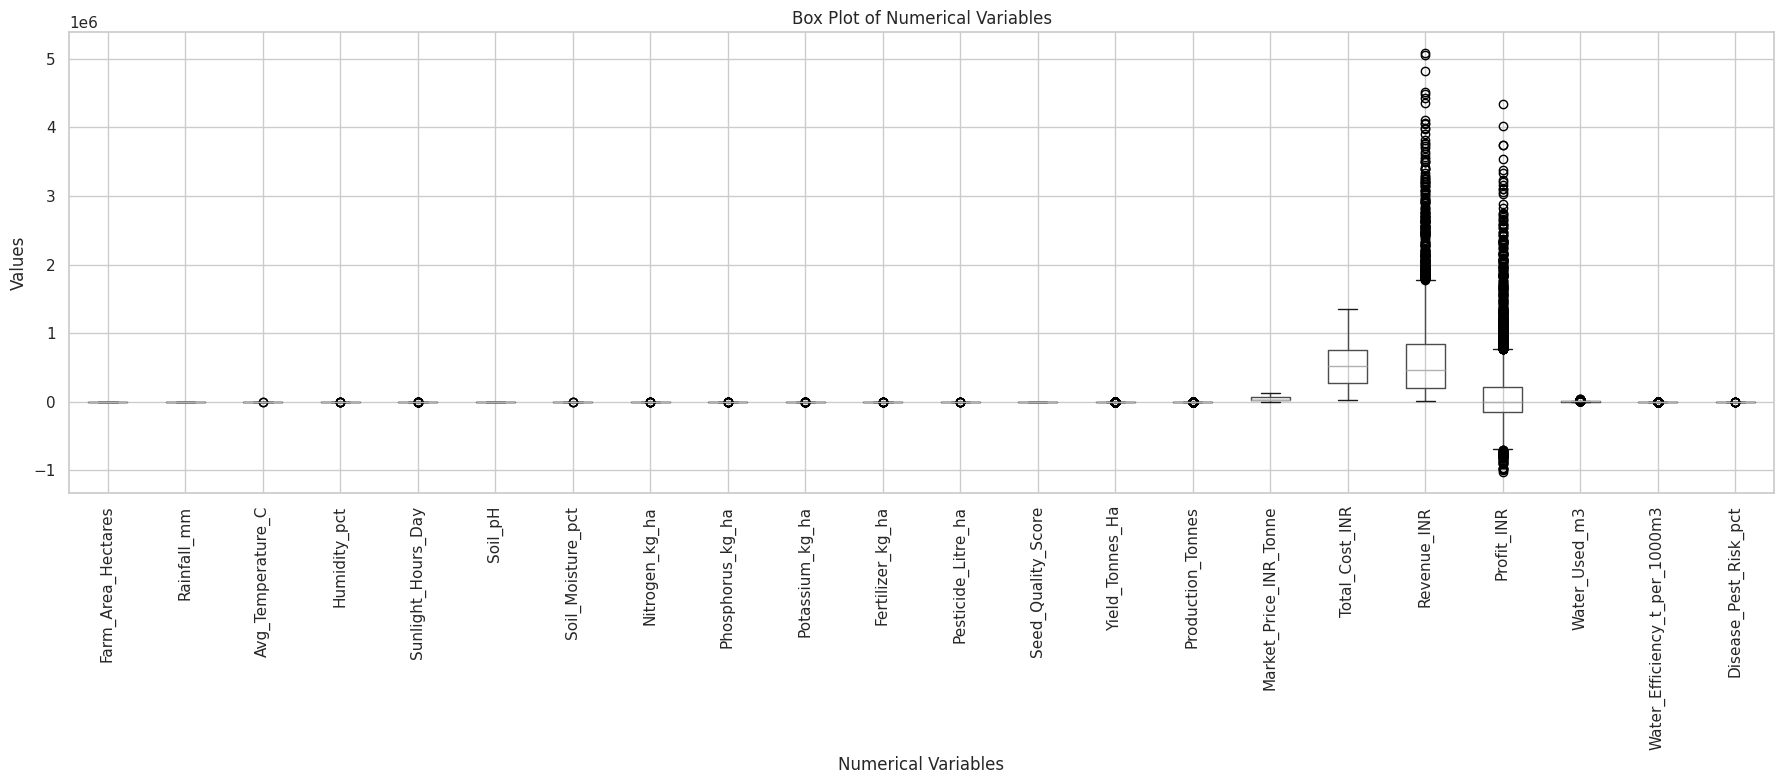

In [15]:
# Box plot for numerical columns

plt.figure(figsize=(18, 8))

df[numerical_columns].boxplot()

plt.title("Box Plot of Numerical Variables")
plt.xlabel("Numerical Variables")
plt.ylabel("Values")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 6. Data Cleaning & Preparation

## 6.1 Cleaning Steps

In [16]:
# Remove duplicate records
df = df.drop_duplicates()

# Fill missing values using median
missing_columns = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']

for column in missing_columns:
    df[column] = df[column].fillna(df[column].median())

# Check the cleaned dataset
print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Records:", df.duplicated().sum())

Total Missing Values: 0
Total Duplicate Records: 0


## 6.2 Final Cleaned Dataset

The cleaned dataset is reviewed to confirm that missing values and duplicate records have been properly handled before further analysis.

In [17]:
# Display the first 5 rows of the final cleaned dataset

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


## 6.3 Final Data Verification

The cleaned dataset is verified to ensure that there are no remaining missing values or duplicate records.

In [18]:
# Verify the final cleaned dataset

print("Total Missing Values:", df.isnull().sum().sum())
print("Total Duplicate Records:", df.duplicated().sum())
print("Dataset Shape:", df.shape)

Total Missing Values: 0
Total Duplicate Records: 0
Dataset Shape: (4000, 28)


## 6.4 Save Cleaned Dataset

The cleaned dataset is saved as a CSV file for future analysis and reference.

In [19]:
# Save the cleaned dataset

df.to_csv("cleaned_agriculture_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# 7. Descriptive and Statistical Analysis

## 7.1 Numerical Variables Summary

The numerical variables are analyzed to identify important statistical patterns, variations and differences in agricultural performance and resource usage.

In [20]:
# Calculate mean, minimum and maximum for important numerical variables

important_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Used_m3'
]

summary = df[important_columns].agg(['mean', 'min', 'max']).T

summary

,mean,min,max
Farm_Area_Hectares,7.89,0.50,15.00
Rainfall_mm,600.92,80.00,1395.20
Yield_Tonnes_Ha,5.24,0.30,101.44
Production_Tonnes,43.25,0.15,1424.40
Profit_INR,111556.46,-1019223.00,4345421.00
Water_Used_m3,6045.57,128.00,40902.00


## 7.2 Categorical Variables Summary

The categorical variables are analyzed to understand the distribution of farms across states, districts, crops, seasons and irrigation methods.

In [21]:
# Display the count of each category

categorical_columns = ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']

for column in categorical_columns:
    print(f"\n{column}:")
    print(df[column].value_counts())


State:
State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

District:
District
Ludhiana    427
Warangal    422
Nalgonda    415
Erode       403
Rajkot      401
Krishna     393
Indore      392
Guntur      390
Raichur     386
Nashik      371
Name: count, dtype: int64

Crop:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Season:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Irrigation_Method:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


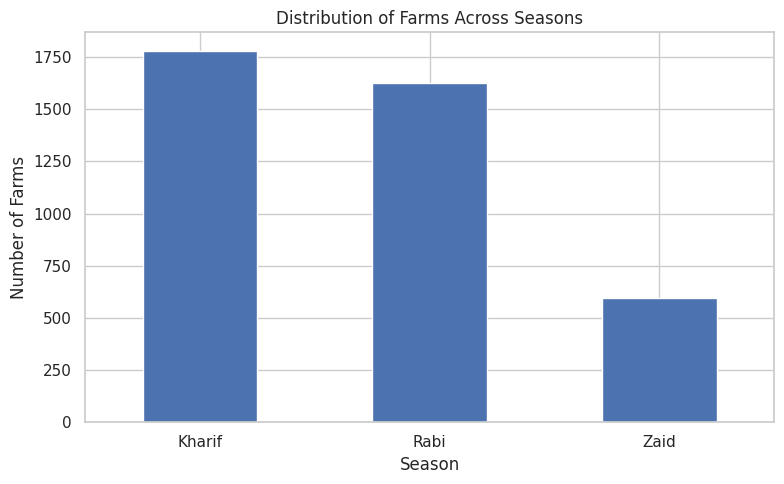

In [22]:
# Bar plot of season distribution

df['Season'].value_counts().plot(kind='bar', figsize=(8, 5))

plt.title("Distribution of Farms Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7.3 Key Statistical Observations

The statistical results are interpreted to identify important variations and patterns in agricultural area, environmental conditions, production, yield, profit and resource usage.

In [23]:
# Display key statistical observations

print("Average Farm Area:", round(df['Farm_Area_Hectares'].mean(), 2), "hectares")
print("Average Yield:", round(df['Yield_Tonnes_Ha'].mean(), 2), "tonnes/ha")
print("Average Production:", round(df['Production_Tonnes'].mean(), 2), "tonnes")
print("Average Profit: ₹", round(df['Profit_INR'].mean(), 2))
print("Average Water Used:", round(df['Water_Used_m3'].mean(), 2), "m³")

Average Farm Area: 7.89 hectares
Average Yield: 5.24 tonnes/ha
Average Production: 43.25 tonnes
Average Profit: ₹ 111556.46
Average Water Used: 6045.57 m³


#8. Univariate Analysis
## 8.1 Crop Distribution

The distribution of different crops is analyzed to understand which crops are most and least represented in the dataset.

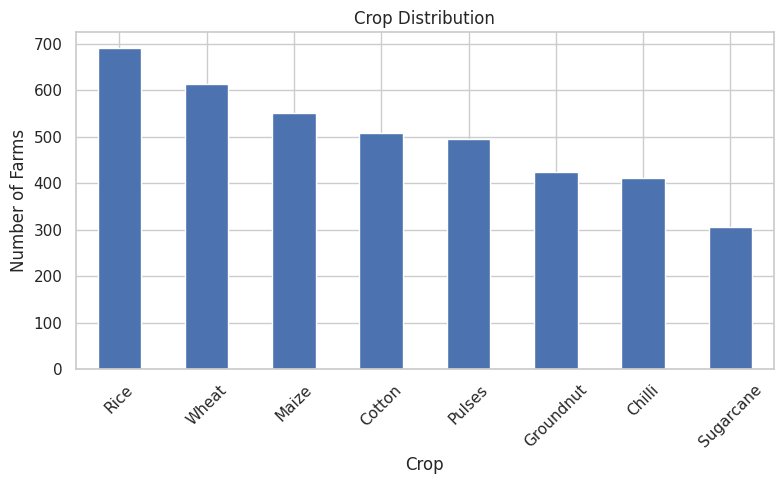

In [24]:
# Bar plot of crop distribution

df['Crop'].value_counts().plot(kind='bar', figsize=(8, 5))

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8.2 Season Distribution

The distribution of farms across different seasons is analyzed to understand the representation of Kharif, Rabi and Zaid seasons in the dataset.

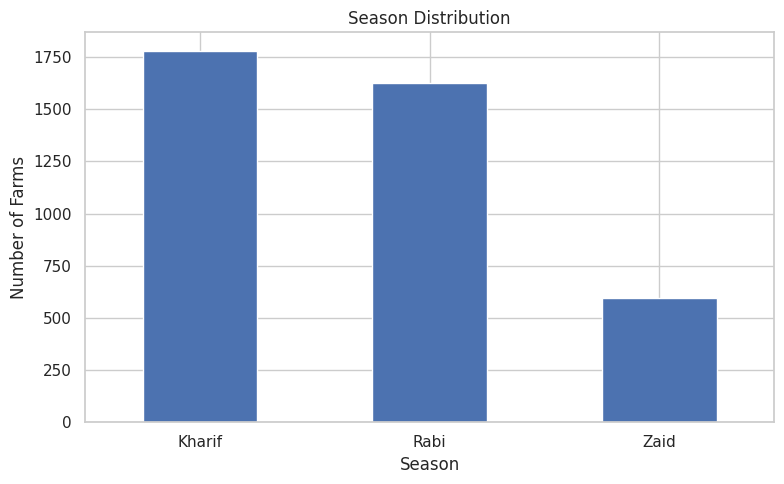

In [25]:
# Bar plot of season distribution

df['Season'].value_counts().plot(kind='bar', figsize=(8, 5))

plt.title("Season Distribution")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8.3 Irrigation Method Distribution

The distribution of irrigation methods is analyzed to understand the use of different irrigation practices across the farms.

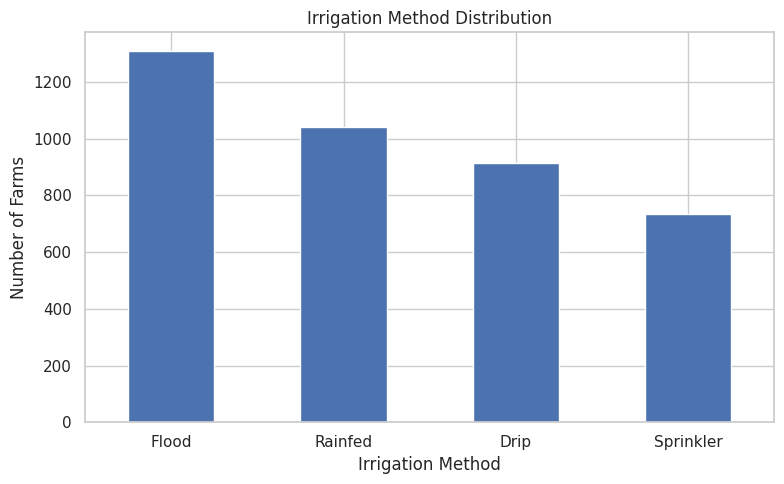

In [26]:
# Bar plot of irrigation method distribution

df['Irrigation_Method'].value_counts().plot(kind='bar', figsize=(8, 5))

plt.title("Irrigation Method Distribution")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8.4 Yield Distribution

The distribution of yield values is analyzed to understand the spread, concentration and variation in agricultural yield across the farms.

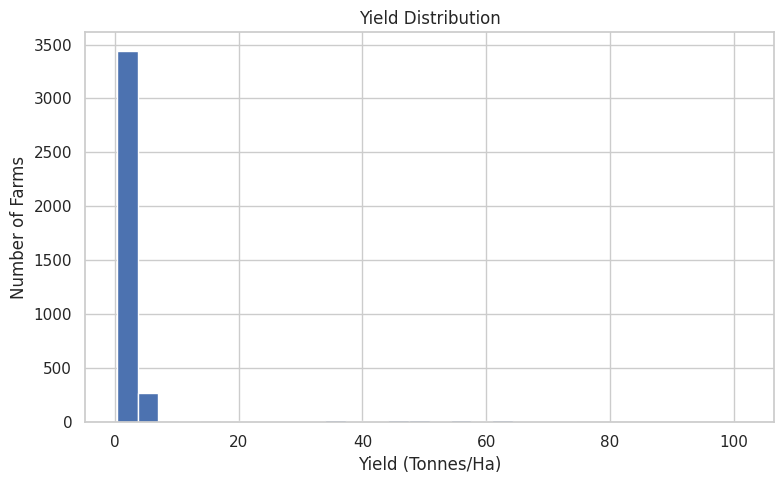

In [27]:
# Histogram of yield distribution

plt.figure(figsize=(8, 5))

plt.hist(df['Yield_Tonnes_Ha'], bins=30)

plt.title("Yield Distribution")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

## 8.5 Profit Distribution

The distribution of profit values is analyzed to understand the variation in economic performance across the farms.

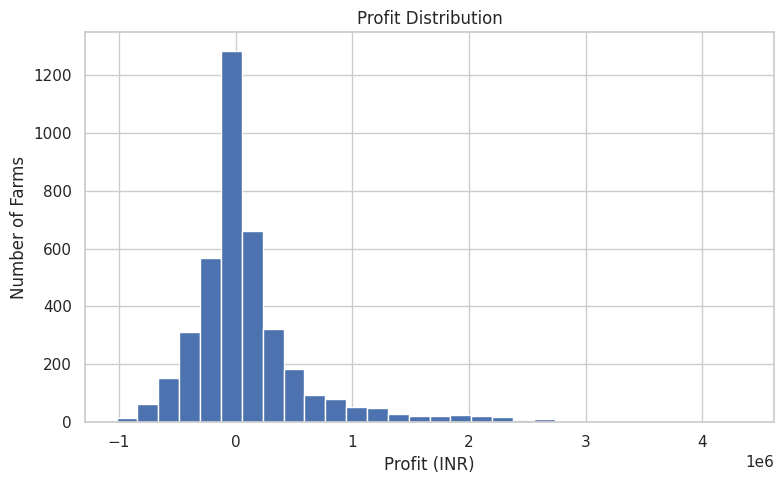

In [28]:
# Histogram of profit distribution

plt.figure(figsize=(8, 5))

plt.hist(df['Profit_INR'], bins=30)

plt.title("Profit Distribution")
plt.xlabel("Profit (INR)")
plt.ylabel("Number of Farms")

plt.tight_layout()
plt.show()

# 9. Bivariate Analysis
## 9.1 Season vs Yield

The average yield is compared across different seasons to understand how seasonal conditions affect agricultural yield.

In [35]:
# Calculate average production for each season

season_production = df.groupby('Season')['Production_Tonnes'].mean()

print(season_production)

Season
Kharif   46.31
Rabi     41.49
Zaid     38.89
Name: Production_Tonnes, dtype: float64


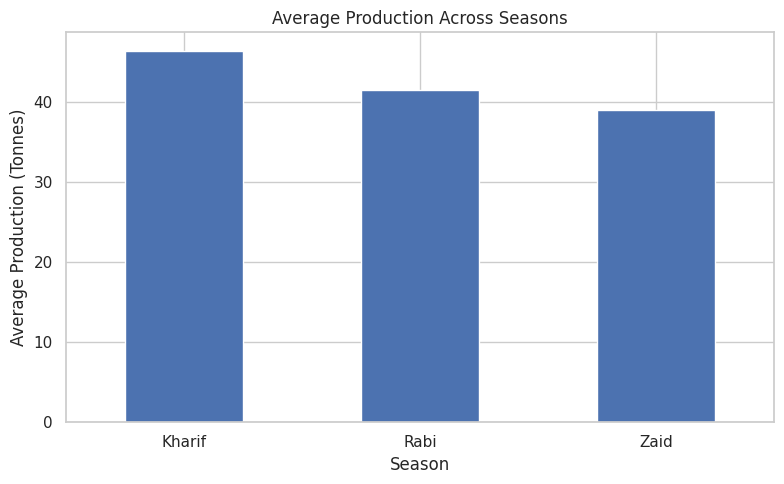

In [36]:
# Bar plot of average production by season

season_production.plot(kind='bar', figsize=(8, 5))

plt.title("Average Production Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9.4 Rainfall vs Yield

The relationship between rainfall and agricultural yield is analyzed to understand whether changes in rainfall are associated with changes in crop yield.

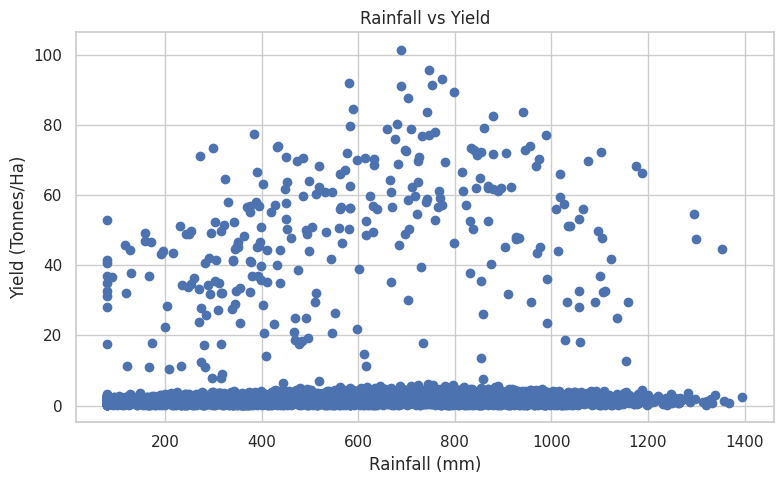

In [37]:
# Scatter plot of rainfall vs yield

plt.figure(figsize=(8, 5))

plt.scatter(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])

plt.title("Rainfall vs Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()

In [38]:
# Calculate correlation between rainfall and yield

rainfall_yield_corr = df['Rainfall_mm'].corr(df['Yield_Tonnes_Ha'])

print("Correlation between Rainfall and Yield:", round(rainfall_yield_corr, 3))

Correlation between Rainfall and Yield: 0.031


## 9.5 Farm Area vs Production

The relationship between farm area and agricultural production is analyzed to understand whether larger farm areas are associated with higher production.

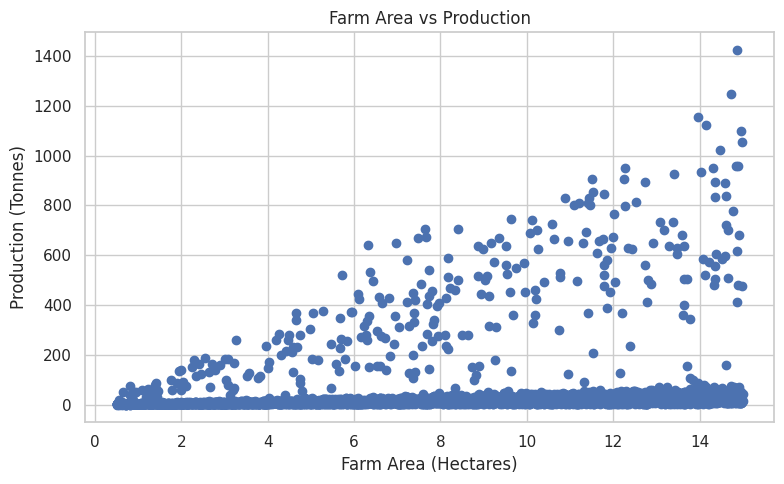

In [39]:
# Scatter plot of farm area vs production

plt.figure(figsize=(8, 5))

plt.scatter(df['Farm_Area_Hectares'], df['Production_Tonnes'])

plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

In [40]:
# Calculate correlation between farm area and production

area_production_corr = df['Farm_Area_Hectares'].corr(df['Production_Tonnes'])

print("Correlation between Farm Area and Production:", round(area_production_corr, 3))

Correlation between Farm Area and Production: 0.198


#10. Multivariate Analysis
## 10.1 Season, Crop and Yield

The average yield is compared across different crops and seasons to understand how crop performance varies under different seasonal conditions.

In [41]:
# Calculate average yield by season and crop

season_crop_yield = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().unstack()

print(season_crop_yield)

Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif    1.73    1.37       1.48   2.97    1.04  2.70      53.46   2.25
Rabi      1.47    1.20       1.23   2.60    0.88  2.32      43.29   2.06
Zaid      1.20    0.96       1.04   2.29    0.67  1.90      38.42   1.75


## 10.2 Season, Irrigation Method and Yield

The average yield is compared across irrigation methods and seasons to understand how irrigation practices are associated with agricultural performance under different seasonal conditions.

In [48]:
# Calculate average profit by season and crop

season_crop_profit = df.groupby(
    ['Season', 'Crop']
)['Profit_INR'].mean().unstack()

print(season_crop_profit)

Crop      Chilli    Cotton  Groundnut      Maize     Pulses       Rice  \
Season                                                                   
Kharif 954380.42 216999.55  108265.44  -39332.67   43338.90  -64903.40   
Rabi   638572.50 107343.59   10416.54  -89133.40  -14309.14  -98427.87   
Zaid   448659.09 -53925.34  -68872.50 -194049.17 -139227.81 -227239.34   

Crop    Sugarcane      Wheat  
Season                        
Kharif 1000790.81 -105871.87  
Rabi    731612.86 -119954.57  
Zaid    583635.80 -193208.95  


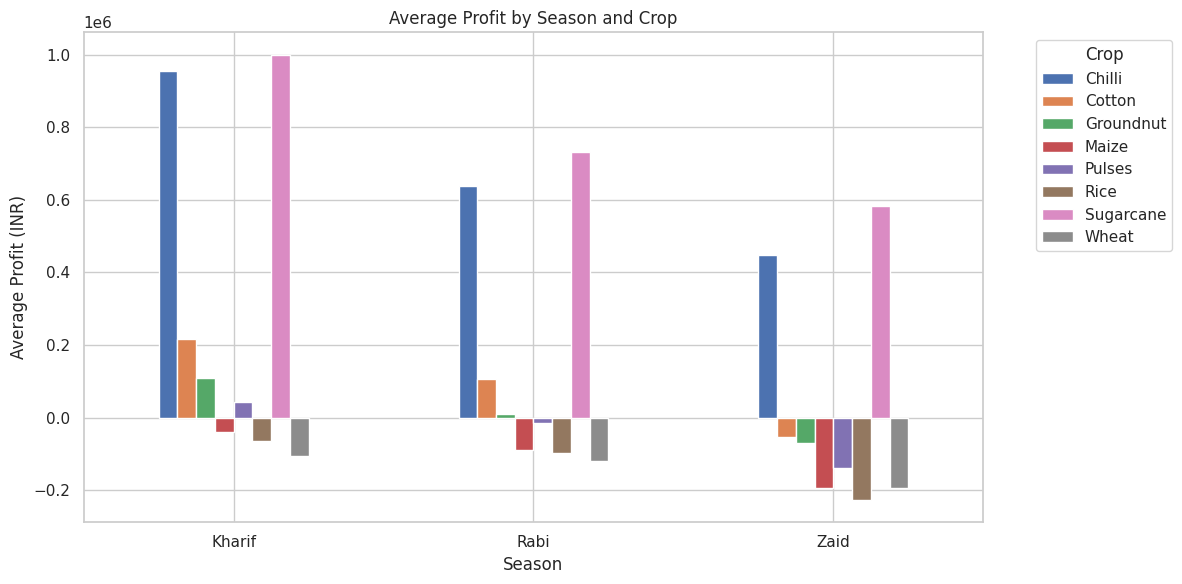

In [49]:
# Bar plot of average profit by season and crop

season_crop_profit.plot(kind='bar', figsize=(12, 6))

plt.title("Average Profit by Season and Crop")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.legend(title="Crop", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#11. Correlation Analysis
##11.1 Correlation Matrix

Description: The correlation matrix is used to examine the strength and direction of relationships among important numerical agricultural variables.

In [50]:
correlation_columns = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]

correlation_matrix = df[correlation_columns].corr()

correlation_matrix

,Farm_Area_Hectares,Rainfall_mm,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
Farm_Area_Hectares,1.00,0.01,0.03,0.20,0.12,0.58,0.03
Rainfall_mm,0.01,1.00,0.03,0.02,0.11,0.00,0.06
Yield_Tonnes_Ha,0.03,0.03,1.00,0.88,0.49,0.39,0.91
Production_Tonnes,0.20,0.02,0.88,1.00,0.55,0.52,0.81
Profit_INR,0.12,0.11,0.49,0.55,1.00,0.19,0.49
Water_Used_m3,0.58,0.00,0.39,0.52,0.19,1.00,0.22
Water_Efficiency_t_per_1000m3,0.03,0.06,0.91,0.81,0.49,0.22,1.00


## 11.2 Correlation Heatmap

The correlation heatmap is used to visually represent the strength and direction of relationships among important numerical agricultural variables.

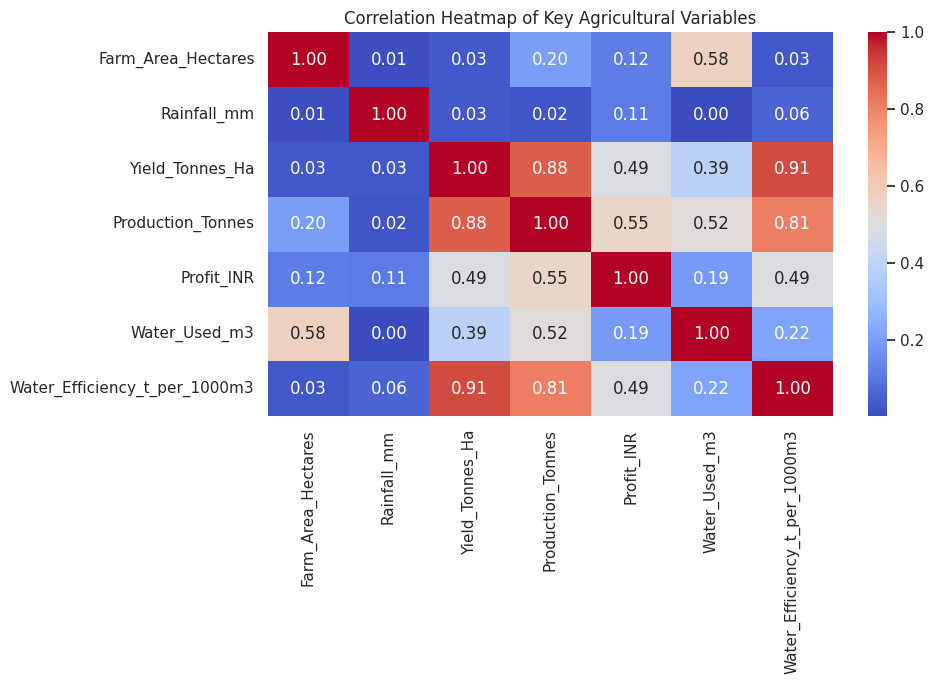

In [51]:
import seaborn as sns

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap of Key Agricultural Variables")
plt.tight_layout()
plt.show()

## 11.3 Important Correlations

The important correlations are identified to understand which agricultural variables have strong, moderate, or weak relationships with each other.

In [52]:
# Display correlations with Yield
yield_correlations = correlation_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False)

print("Important Correlations with Yield:")
print(yield_correlations)

Important Correlations with Yield:
Yield_Tonnes_Ha                 1.00
Water_Efficiency_t_per_1000m3   0.91
Production_Tonnes               0.88
Profit_INR                      0.49
Water_Used_m3                   0.39
Rainfall_mm                     0.03
Farm_Area_Hectares              0.03
Name: Yield_Tonnes_Ha, dtype: float64


# 12. Seasonal Performance Analysis
## 12.1 Overall Seasonal Performance

The overall agricultural performance is compared across different seasons to understand how seasonal conditions affect yield, production, and profit.

In [53]:
season_performance = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']
].mean()

print(season_performance)

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.63              46.31   178914.65
Rabi               5.04              41.49    87689.47
Zaid               4.64              38.89   -24804.82


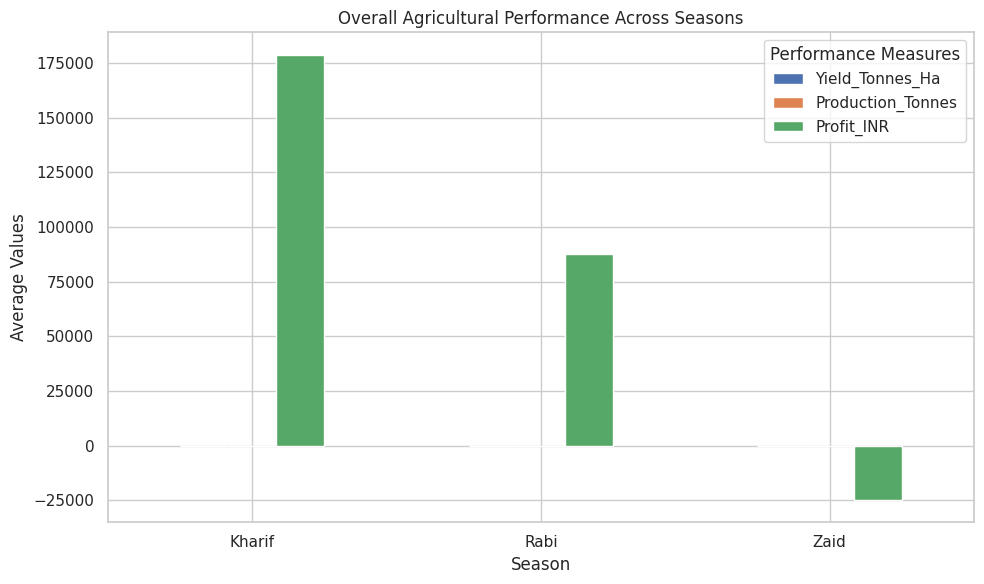

In [54]:
season_performance.plot(kind='bar', figsize=(10, 6))

plt.title("Overall Agricultural Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.legend(title="Performance Measures")

plt.tight_layout()
plt.show()

## 12.2 Seasonal Yield Comparison

The average yield is compared across different seasons to identify which season has the highest and lowest agricultural yield.

In [55]:
seasonal_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

print("Average Yield by Season:")
print(seasonal_yield)

Average Yield by Season:
Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64


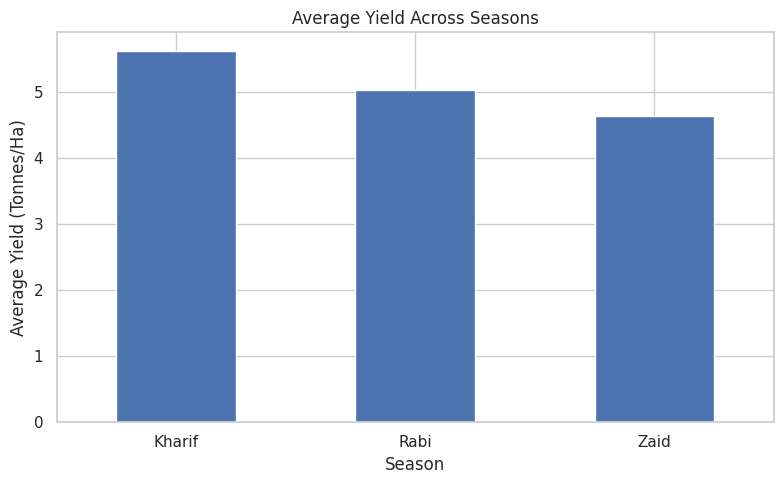

In [56]:
seasonal_yield.plot(kind='bar', figsize=(8, 5))

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 12.3 Seasonal Production Comparison

The average agricultural production is compared across different seasons to identify seasonal differences in production levels.

In [57]:
seasonal_production = df.groupby('Season')['Production_Tonnes'].mean()

print("Average Production by Season:")
print(seasonal_production)

Average Production by Season:
Season
Kharif   46.31
Rabi     41.49
Zaid     38.89
Name: Production_Tonnes, dtype: float64


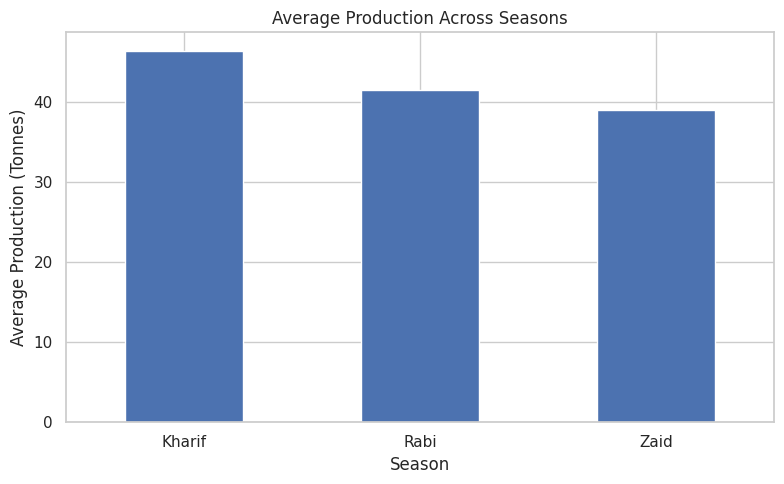

In [58]:
seasonal_production.plot(kind='bar', figsize=(8, 5))

plt.title("Average Production Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Production (Tonnes)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 12.4 Seasonal Profit Comparison

The average profit is compared across different seasons to identify seasonal differences in economic performance.

In [59]:
seasonal_profit = df.groupby('Season')['Profit_INR'].mean()

print("Average Profit by Season:")
print(seasonal_profit)

Average Profit by Season:
Season
Kharif   178914.65
Rabi      87689.47
Zaid     -24804.82
Name: Profit_INR, dtype: float64


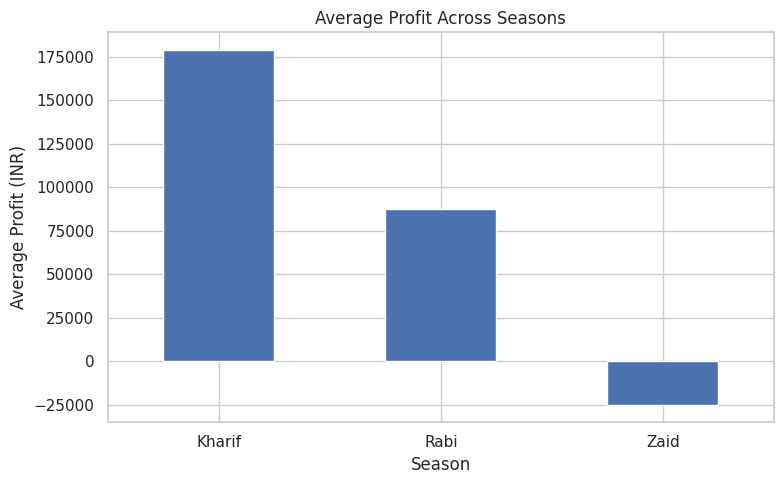

In [60]:
seasonal_profit.plot(kind='bar', figsize=(8, 5))

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 12.5 Seasonal Resource Usage

The average resource usage is compared across different seasons to understand how agricultural resource requirements vary with seasonal conditions.

In [68]:
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [69]:
seasonal_resource_usage = df.groupby('Season')[
    ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']
].mean()

print("Average Resource Usage by Season:")
print(seasonal_resource_usage)

Average Resource Usage by Season:
        Water_Used_m3  Fertilizer_kg_ha  Pesticide_Litre_ha
Season                                                     
Kharif        6102.20            187.08                5.08
Rabi          5846.99            185.41                5.02
Zaid          6419.89            184.64                5.17


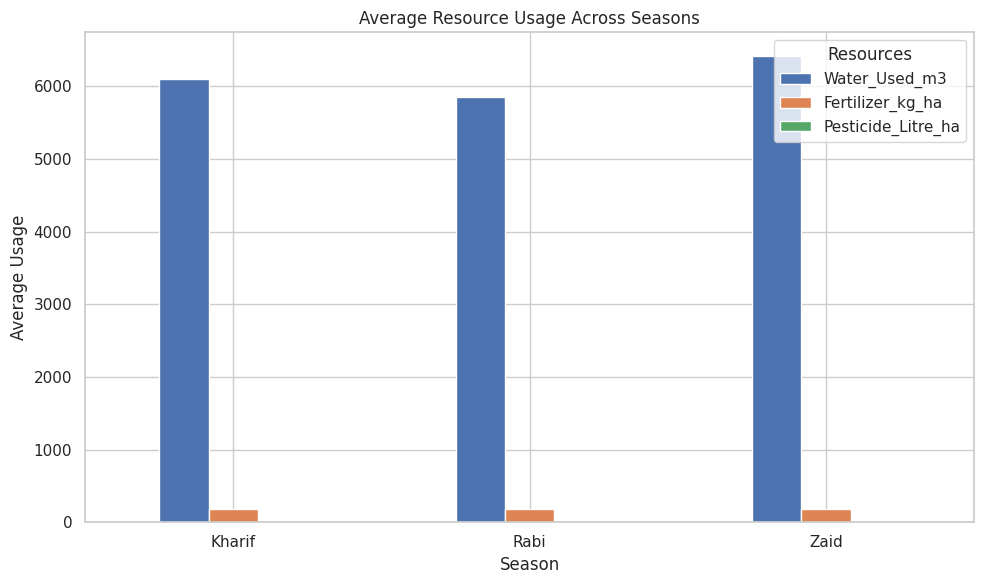

In [70]:
seasonal_resource_usage.plot(kind='bar', figsize=(10, 6))

plt.title("Average Resource Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Usage")
plt.xticks(rotation=0)
plt.legend(title="Resources")

plt.tight_layout()
plt.show()

## 12.6 Seasonal Environmental Conditions

The average environmental conditions are compared across different seasons to understand how rainfall, temperature, humidity, sunlight, and soil moisture vary with seasonal changes.

In [71]:
seasonal_environment = df.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct'
    ]
].mean()

print("Average Environmental Conditions by Season:")
print(seasonal_environment)

Average Environmental Conditions by Season:
        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif       849.20              28.45         71.81                6.79   
Rabi         437.62              23.49         57.89                7.59   
Zaid         304.65              31.04         52.01                8.18   

        Soil_Moisture_pct  
Season                     
Kharif              31.15  
Rabi                24.07  
Zaid                19.28  


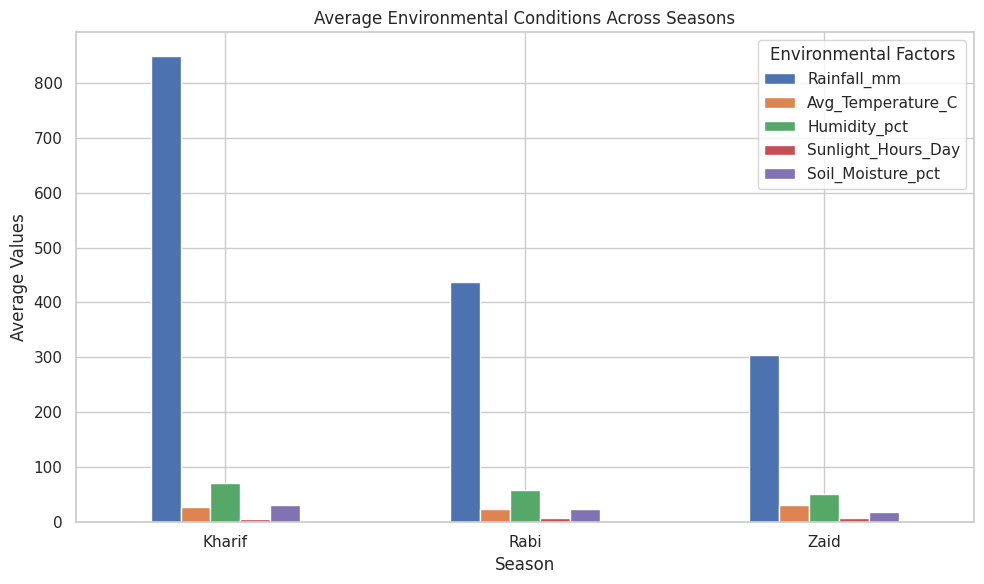

In [72]:
seasonal_environment.plot(kind='bar', figsize=(10, 6))

plt.title("Average Environmental Conditions Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Values")
plt.xticks(rotation=0)
plt.legend(title="Environmental Factors")

plt.tight_layout()
plt.show()

# 13. Seasonal Comparison Across Groups
## 13.1 Crop Performance Across Seasons

The average yield of different crops is compared across seasons to identify how crop performance varies under different seasonal conditions.

In [73]:
crop_season_yield = df.groupby(
    ['Season', 'Crop']
)['Yield_Tonnes_Ha'].mean().unstack()

print("Average Yield by Crop and Season:")
print(crop_season_yield)

Average Yield by Crop and Season:
Crop    Chilli  Cotton  Groundnut  Maize  Pulses  Rice  Sugarcane  Wheat
Season                                                                  
Kharif    1.73    1.37       1.48   2.97    1.04  2.70      53.46   2.25
Rabi      1.47    1.20       1.23   2.60    0.88  2.32      43.29   2.06
Zaid      1.20    0.96       1.04   2.29    0.67  1.90      38.42   1.75


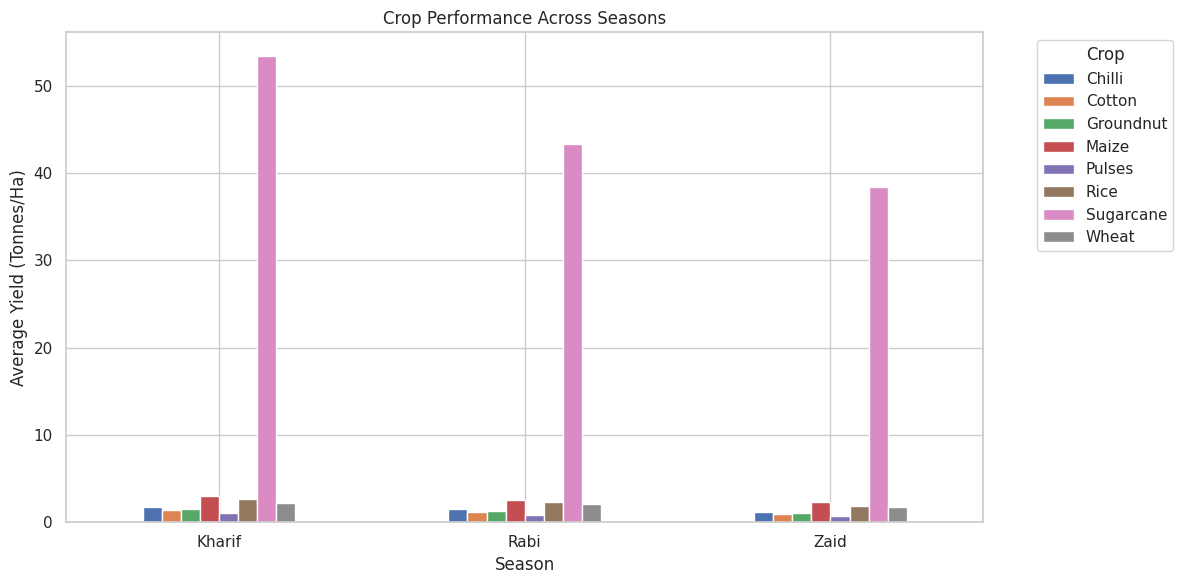

In [74]:
crop_season_yield.plot(kind='bar', figsize=(12, 6))

plt.title("Crop Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.legend(title="Crop", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 13.2 Irrigation Performance Across Seasons

The average yield of different irrigation methods is compared across seasons to identify how irrigation practices affect agricultural performance under seasonal conditions.

In [75]:
irrigation_season_yield = df.groupby(
    ['Season', 'Irrigation_Method']
)['Yield_Tonnes_Ha'].mean().unstack()

print("Average Yield by Irrigation Method and Season:")
print(irrigation_season_yield)

Average Yield by Irrigation Method and Season:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             7.26   4.98     5.70       4.66
Rabi               6.11   5.06     3.93       5.31
Zaid               5.85   3.98     3.06       6.14


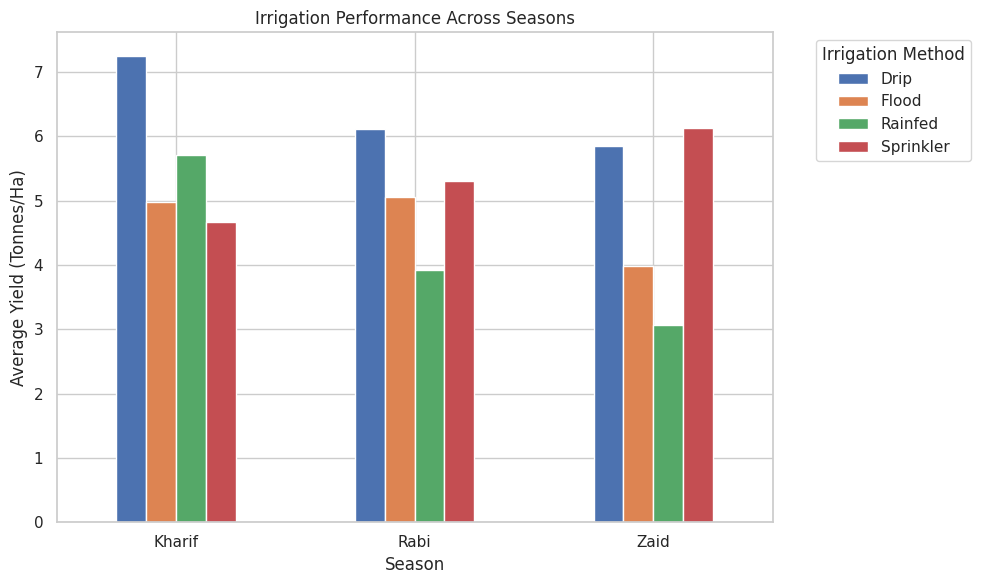

In [76]:
irrigation_season_yield.plot(kind='bar', figsize=(10, 6))

plt.title("Irrigation Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 13.3 Regional Performance Across Seasons

The average agricultural performance is compared across different states and seasons to identify regional differences in agricultural outcomes under seasonal conditions.

In [77]:
regional_season_performance = df.groupby(
    ['Season', 'State']
)[['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']].mean()

print("Average Agricultural Performance by State and Season:")
print(regional_season_performance)

Average Agricultural Performance by State and Season:
                       Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season State                                                         
Kharif Andhra Pradesh             5.68              46.23   169315.52
       Gujarat                    6.34              54.53   217051.33
       Karnataka                  6.46              56.39   201226.21
       Madhya Pradesh             5.99              43.81   134242.40
       Maharashtra                5.43              44.42   168801.05
       Punjab                     4.10              31.76   133779.10
       Tamil Nadu                 5.52              53.11   211303.96
       Telangana                  5.55              41.60   199668.38
Rabi   Andhra Pradesh             3.47              26.53    26315.71
       Gujarat                    5.44              47.55    82846.20
       Karnataka                  4.57              37.11    70952.61
       Madhya Pradesh             3.

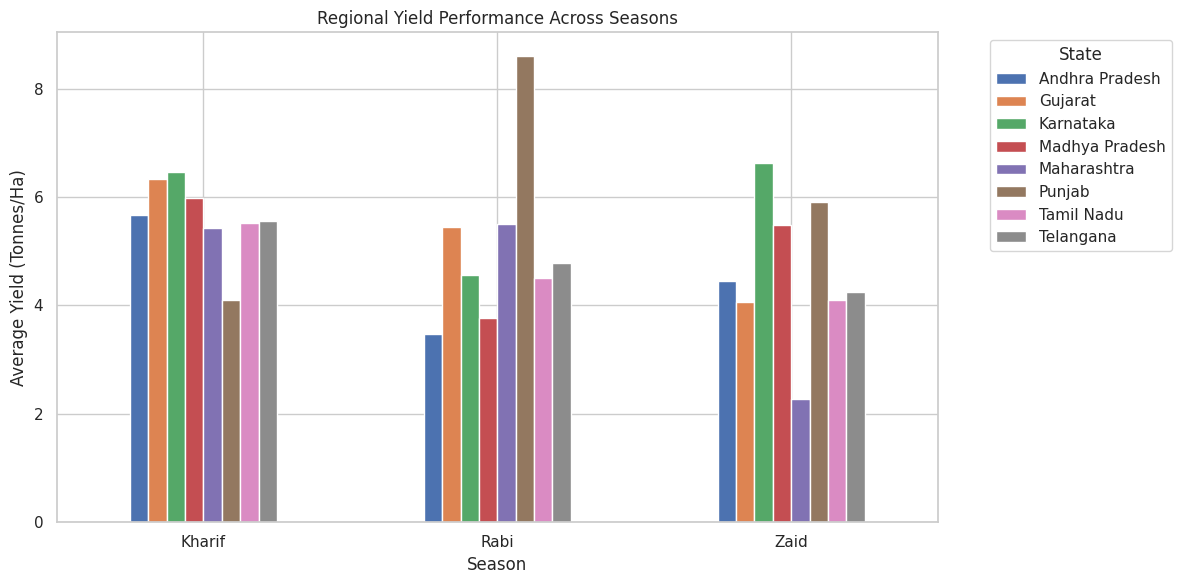

In [78]:
regional_season_performance['Yield_Tonnes_Ha'].unstack().plot(
    kind='bar', figsize=(12, 6)
)

plt.title("Regional Yield Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 13.4 Economic Performance Across Seasons

The average revenue, total cost, and profit are compared across different seasons to identify seasonal differences in the economic performance of agricultural activities.

In [79]:
economic_season = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()

print("Average Economic Performance by Season:")
print(economic_season)

Average Economic Performance by Season:
        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif    710719.06       531804.41   178914.65
Rabi      601526.05       513836.58    87689.47
Zaid      519171.90       543976.73   -24804.82


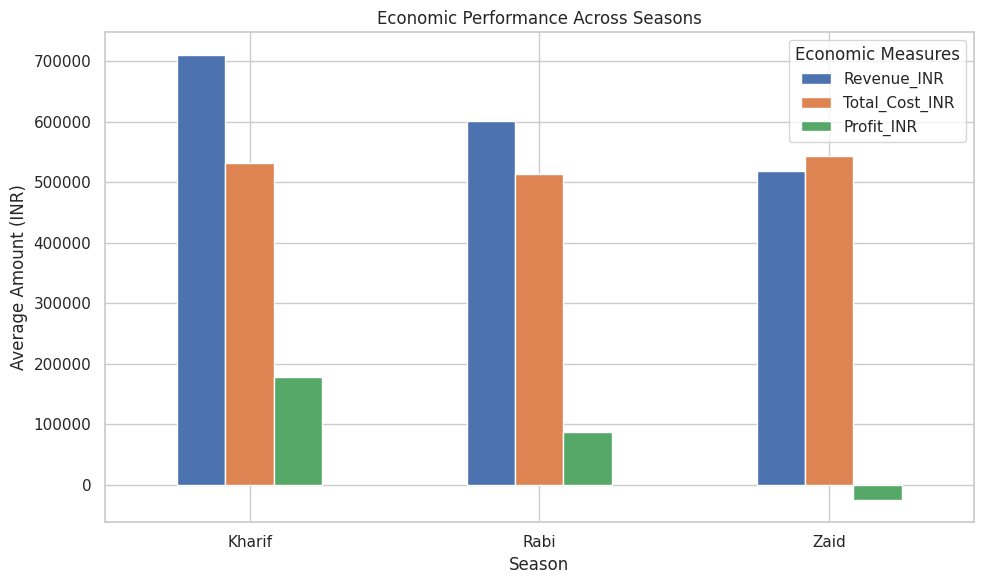

In [80]:
economic_season.plot(kind='bar', figsize=(10, 6))

plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Amount (INR)")
plt.xticks(rotation=0)
plt.legend(title="Economic Measures")

plt.tight_layout()
plt.show()

# 14. Student-Designed Analysis 1

## 14.1 Analytical Question

Which crop provides the highest average profit across different seasons?

In [81]:
crop_season_profit = df.groupby(
    ['Season', 'Crop']
)['Profit_INR'].mean().unstack()

print("Average Profit by Crop and Season:")
print(crop_season_profit)

Average Profit by Crop and Season:
Crop      Chilli    Cotton  Groundnut      Maize     Pulses       Rice  \
Season                                                                   
Kharif 954380.42 216999.55  108265.44  -39332.67   43338.90  -64903.40   
Rabi   638572.50 107343.59   10416.54  -89133.40  -14309.14  -98427.87   
Zaid   448659.09 -53925.34  -68872.50 -194049.17 -139227.81 -227239.34   

Crop    Sugarcane      Wheat  
Season                        
Kharif 1000790.81 -105871.87  
Rabi    731612.86 -119954.57  
Zaid    583635.80 -193208.95  


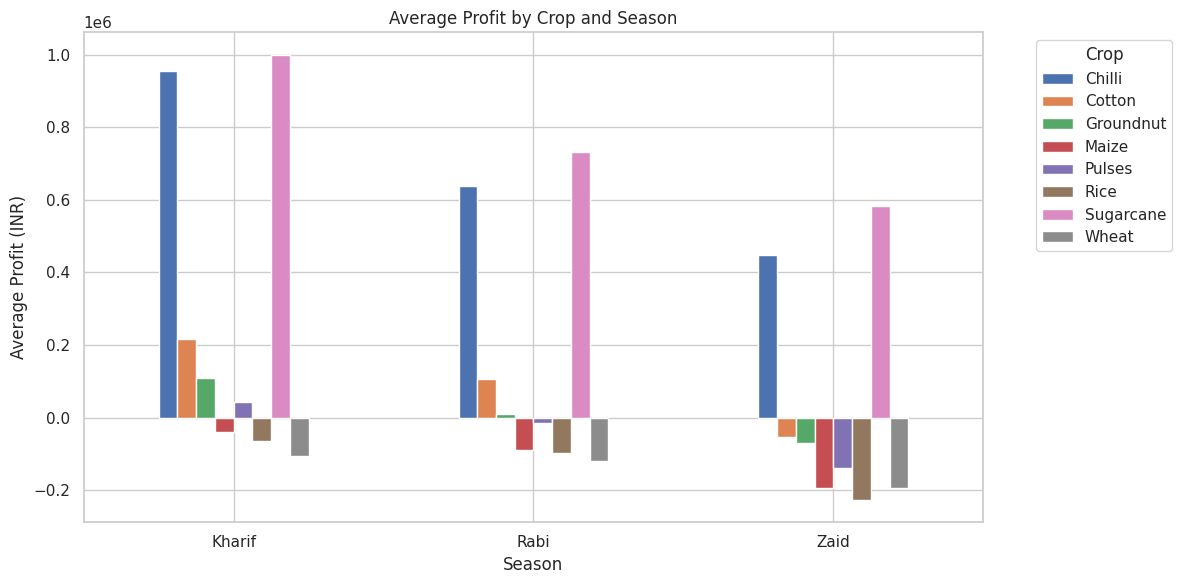

In [82]:
crop_season_profit.plot(kind='bar', figsize=(12, 6))

plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.legend(title="Crop", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 14.2 Analysis

The average profit of each crop is analyzed across seasons to identify the crop with the highest economic performance.

In [83]:
# Find the crop with the highest average profit in each season
highest_profit_crop = crop_season_profit.idxmax(axis=1)
highest_profit_value = crop_season_profit.max(axis=1)

result = pd.DataFrame({
    'Crop': highest_profit_crop,
    'Average_Profit_INR': highest_profit_value
})

print("Highest Profit Crop by Season:")
print(result)

Highest Profit Crop by Season:
             Crop  Average_Profit_INR
Season                               
Kharif  Sugarcane          1000790.81
Rabi    Sugarcane           731612.86
Zaid    Sugarcane           583635.80


## 14.3 Visualization

A bar chart is used to visualize the average profit of different crops across seasons and identify the highest-performing crop.

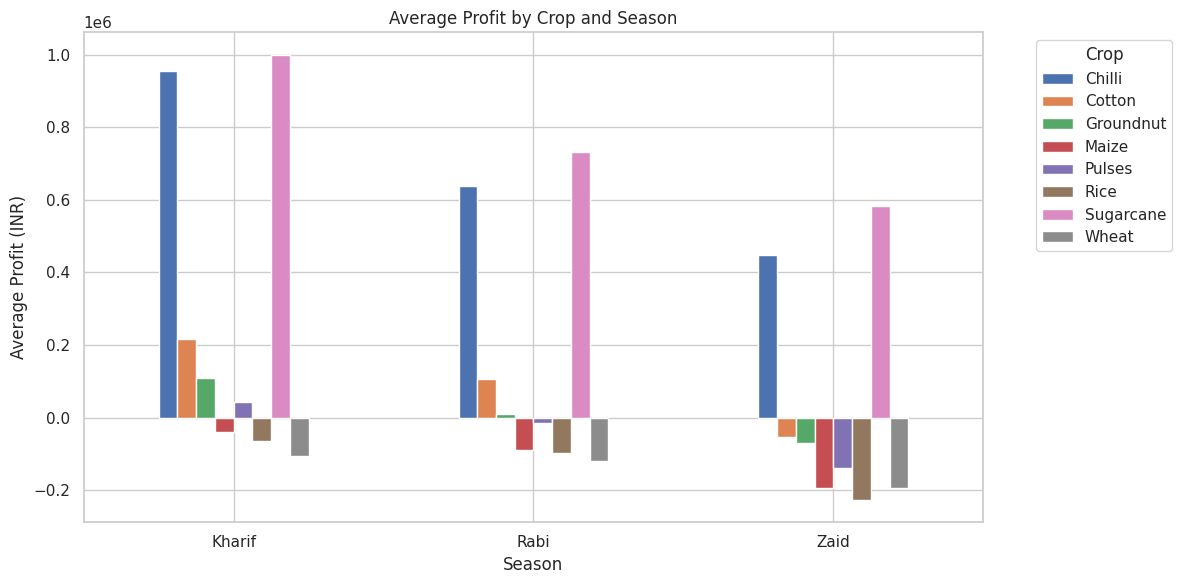

In [84]:
crop_season_profit.plot(kind='bar', figsize=(12, 6))

plt.title("Average Profit by Crop and Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.legend(title="Crop", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 14.4 Interpretation

The analysis identifies the crops with higher and lower average profit across seasons, helping to understand which crop choices show better economic performance under different seasonal conditions.

In [85]:
print("Highest Profit Crop by Season:")
print(result)

Highest Profit Crop by Season:
             Crop  Average_Profit_INR
Season                               
Kharif  Sugarcane          1000790.81
Rabi    Sugarcane           731612.86
Zaid    Sugarcane           583635.80


# 15. Student-Designed Analysis 2

## 15.1 Analytical Question

Which irrigation method provides the highest average yield across different seasons?

In [87]:
irrigation_season_yield = df.groupby(
    ['Season', 'Irrigation_Method']
)['Yield_Tonnes_Ha'].mean().unstack()

print("Average Yield by Irrigation Method and Season:")
print(irrigation_season_yield)

Average Yield by Irrigation Method and Season:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             7.26   4.98     5.70       4.66
Rabi               6.11   5.06     3.93       5.31
Zaid               5.85   3.98     3.06       6.14


## 15.2 Analysis

The average yield is analyzed for each irrigation method across seasons to identify which irrigation method shows better agricultural performance.

In [88]:
print("Average Yield by Irrigation Method and Season:")
print(irrigation_season_yield)

Average Yield by Irrigation Method and Season:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             7.26   4.98     5.70       4.66
Rabi               6.11   5.06     3.93       5.31
Zaid               5.85   3.98     3.06       6.14


## 15.3 Visualization

A bar chart is used to compare the average yield of different irrigation methods across seasons.

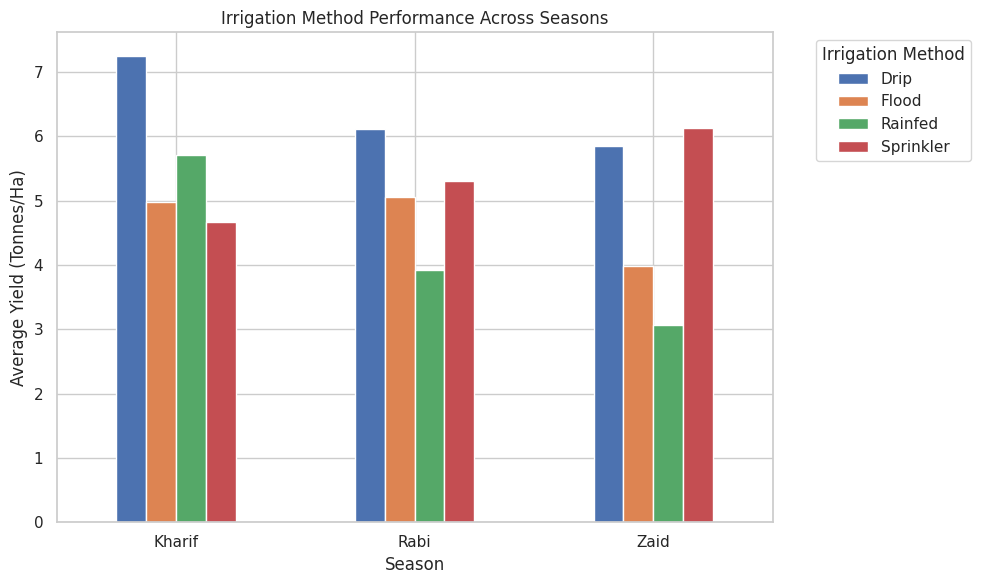

In [89]:
irrigation_season_yield.plot(kind='bar', figsize=(10, 6))

plt.title("Irrigation Method Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.legend(title="Irrigation Method", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 15.4 Interpretation

The analysis helps identify which irrigation methods provide higher average yields across different seasons and highlights seasonal differences in irrigation performance.

In [90]:
highest_yield_irrigation = irrigation_season_yield.idxmax(axis=1)
highest_yield_value = irrigation_season_yield.max(axis=1)

irrigation_result = pd.DataFrame({
    'Irrigation_Method': highest_yield_irrigation,
    'Average_Yield_Tonnes_Ha': highest_yield_value
})

print("Highest Yield Irrigation Method by Season:")
print(irrigation_result)

Highest Yield Irrigation Method by Season:
       Irrigation_Method  Average_Yield_Tonnes_Ha
Season                                           
Kharif              Drip                     7.26
Rabi                Drip                     6.11
Zaid           Sprinkler                     6.14


# 16. Student-Designed Analysis 3

## 16.1 Analytical Question

How does water usage affect agricultural production across different seasons?

In [91]:
seasonal_water_production = df.groupby('Season')[
    ['Water_Used_m3', 'Production_Tonnes']
].mean()

print("Average Water Usage and Production by Season:")
print(seasonal_water_production)

Average Water Usage and Production by Season:
        Water_Used_m3  Production_Tonnes
Season                                  
Kharif        6102.20              46.31
Rabi          5846.99              41.49
Zaid          6419.89              38.89


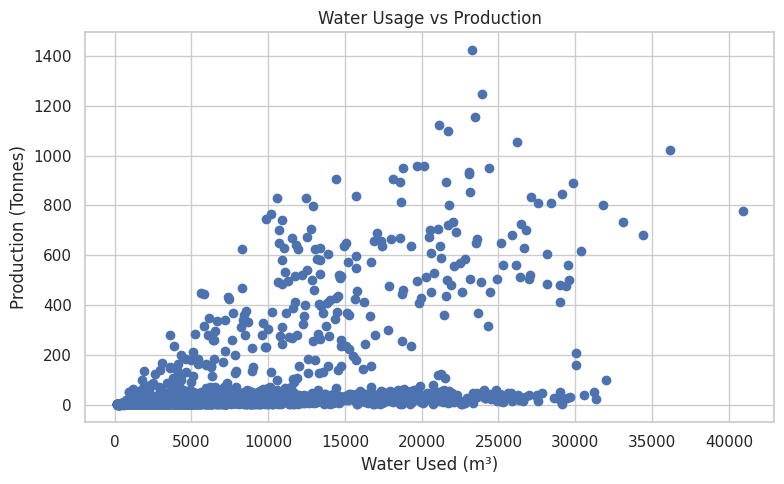

In [92]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Water_Used_m3'],
    df['Production_Tonnes']
)

plt.title("Water Usage vs Production")
plt.xlabel("Water Used (m³)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

## 16.2 Analysis

The relationship between water usage and agricultural production is analyzed across seasons to understand whether higher water usage is associated with higher production.

In [93]:
water_production_corr = df['Water_Used_m3'].corr(
    df['Production_Tonnes']
)

print(
    "Correlation between Water Usage and Production:",
    round(water_production_corr, 3)
)

Correlation between Water Usage and Production: 0.516


## 16.3 Visualization

A scatter plot is used to visualize the relationship between water usage and agricultural production across the dataset.

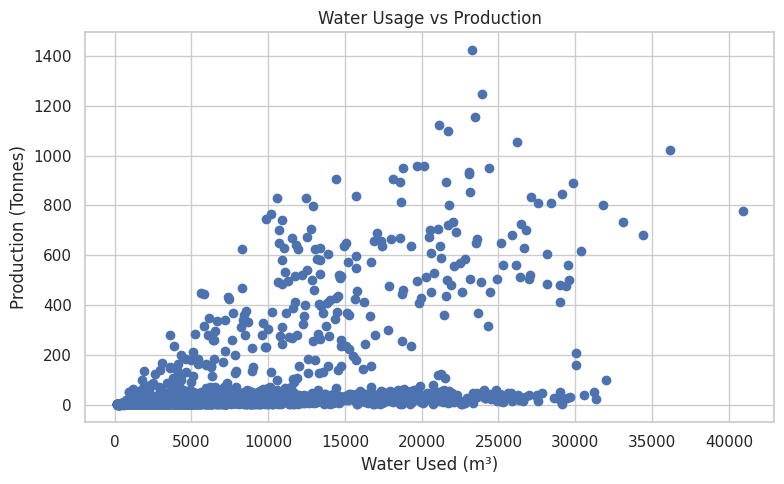

In [94]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['Water_Used_m3'],
    df['Production_Tonnes']
)

plt.title("Water Usage vs Production")
plt.xlabel("Water Used (m³)")
plt.ylabel("Production (Tonnes)")

plt.tight_layout()
plt.show()

## 16.4 Interpretation

The analysis helps determine whether higher water usage is associated with higher agricultural production and provides insight into water resource utilization.

In [95]:
print("Correlation between Water Usage and Production:",
      round(water_production_corr, 3))

if water_production_corr > 0:
    print("Higher water usage is associated with higher production.")
elif water_production_corr < 0:
    print("Higher water usage is associated with lower production.")
else:
    print("There is no linear relationship between water usage and production.")

Correlation between Water Usage and Production: 0.516
Higher water usage is associated with higher production.


# 17. Key Insights
## 17.1 Seasonal Insights

The seasonal analysis highlights differences in yield, production, profit, resource usage, and environmental conditions across Kharif, Rabi, and Zaid seasons.

In [96]:
seasonal_insights = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR',
     'Water_Used_m3', 'Rainfall_mm']
].mean()

print("Seasonal Performance Insights:")
print(seasonal_insights)

Seasonal Performance Insights:
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR  Water_Used_m3  \
Season                                                                  
Kharif             5.63              46.31   178914.65        6102.20   
Rabi               5.04              41.49    87689.47        5846.99   
Zaid               4.64              38.89   -24804.82        6419.89   

        Rainfall_mm  
Season               
Kharif       849.20  
Rabi         437.62  
Zaid         304.65  


## 17.2 Environmental Insights

The environmental analysis highlights how rainfall, temperature, humidity, sunlight, and soil moisture vary across seasons and their relationship with agricultural performance.

In [97]:
environmental_insights = df.groupby('Season')[
    [
        'Rainfall_mm',
        'Avg_Temperature_C',
        'Humidity_pct',
        'Sunlight_Hours_Day',
        'Soil_Moisture_pct'
    ]
].mean()

print("Environmental Insights by Season:")
print(environmental_insights)

Environmental Insights by Season:
        Rainfall_mm  Avg_Temperature_C  Humidity_pct  Sunlight_Hours_Day  \
Season                                                                     
Kharif       849.20              28.45         71.81                6.79   
Rabi         437.62              23.49         57.89                7.59   
Zaid         304.65              31.04         52.01                8.18   

        Soil_Moisture_pct  
Season                     
Kharif              31.15  
Rabi                24.07  
Zaid                19.28  


## 17.3 Production and Yield Insights

The production and yield analysis highlights the differences in agricultural output across seasons, crops, and irrigation methods.

In [98]:
production_yield_insights = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes']
].mean()

print("Production and Yield Insights by Season:")
print(production_yield_insights)

Production and Yield Insights by Season:
        Yield_Tonnes_Ha  Production_Tonnes
Season                                    
Kharif             5.63              46.31
Rabi               5.04              41.49
Zaid               4.64              38.89


## 17.4 Economic Insights

The economic analysis highlights differences in revenue, cost, and profit across seasons to identify the seasonal factors associated with better economic performance.

In [99]:
economic_insights = df.groupby('Season')[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].mean()

print("Economic Insights by Season:")
print(economic_insights)

Economic Insights by Season:
        Revenue_INR  Total_Cost_INR  Profit_INR
Season                                         
Kharif    710719.06       531804.41   178914.65
Rabi      601526.05       513836.58    87689.47
Zaid      519171.90       543976.73   -24804.82


# 18. Evidence-Based Recommendations
## 18.1 Seasonal Recommendations

Based on the seasonal analysis, farmers can prioritize seasons with higher yield and profitability while considering seasonal environmental conditions and resource requirements.

In [100]:
seasonal_recommendation = df.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Profit_INR']
].mean()

best_season = seasonal_recommendation['Profit_INR'].idxmax()

print("Seasonal Performance:")
print(seasonal_recommendation)

print("\nRecommended Season Based on Average Profit:", best_season)


Seasonal Performance:
        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.63              46.31   178914.65
Rabi               5.04              41.49    87689.47
Zaid               4.64              38.89   -24804.82

Recommended Season Based on Average Profit: Kharif


## 18.2 Resource Management Recommendations

Based on the analysis of water, fertilizer, and pesticide usage across seasons, farmers can optimize resource usage by selecting suitable irrigation methods and avoiding unnecessary use of agricultural inputs.

In [102]:
resource_recommendation = df.groupby('Season')[
    ['Water_Used_m3', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha']
].mean()

print("Average Resource Usage by Season:")
print(resource_recommendation)

print("\nRecommended Approach:")
print("Use resources efficiently according to seasonal requirements and prefer suitable irrigation methods to reduce unnecessary water usage.")

Average Resource Usage by Season:
        Water_Used_m3  Fertilizer_kg_ha  Pesticide_Litre_ha
Season                                                     
Kharif        6102.20            187.08                5.08
Rabi          5846.99            185.41                5.02
Zaid          6419.89            184.64                5.17

Recommended Approach:
Use resources efficiently according to seasonal requirements and prefer suitable irrigation methods to reduce unnecessary water usage.


## 18.3 Crop and Irrigation Recommendations

Based on the analysis, farmers can select crops and irrigation methods that show better yield and profitability under different seasonal conditions.

In [103]:
crop_irrigation_recommendation = df.groupby(
    ['Season', 'Irrigation_Method']
)['Yield_Tonnes_Ha'].mean().unstack()

print("Average Yield by Irrigation Method and Season:")
print(crop_irrigation_recommendation)

best_irrigation = crop_irrigation_recommendation.idxmax(axis=1)

print("\nRecommended Irrigation Method by Season:")
print(best_irrigation)

Average Yield by Irrigation Method and Season:
Irrigation_Method  Drip  Flood  Rainfed  Sprinkler
Season                                            
Kharif             7.26   4.98     5.70       4.66
Rabi               6.11   5.06     3.93       5.31
Zaid               5.85   3.98     3.06       6.14

Recommended Irrigation Method by Season:
Season
Kharif         Drip
Rabi           Drip
Zaid      Sprinkler
dtype: object


# 19. Limitations
## 19.1 Dataset Limitations

The dataset may not represent all agricultural regions, crops, seasons, and farming conditions, so the findings may not be fully generalizable to all agricultural situations.

In [104]:
print("Dataset Limitation:")
print("The dataset may not represent all agricultural regions, crops, seasons, and farming conditions.")
print("Therefore, the findings may not be fully generalizable to all agricultural situations.")

Dataset Limitation:
The dataset may not represent all agricultural regions, crops, seasons, and farming conditions.
Therefore, the findings may not be fully generalizable to all agricultural situations.


## 19.2 Analysis Limitations

The analysis is based on the available dataset and selected variables, so external factors such as market changes, weather variations, farming practices, and local conditions may also influence the results.

In [105]:
print("Analysis Limitations:")
print("The analysis is based on the available dataset and selected variables.")
print("External factors such as market changes, weather variations, farming practices, and local conditions may also influence the results.")

Analysis Limitations:
The analysis is based on the available dataset and selected variables.
External factors such as market changes, weather variations, farming practices, and local conditions may also influence the results.


# 20. Conclusion
## 20.1 Overall Findings

The analysis shows clear differences in agricultural performance across seasons, crops, irrigation methods, environmental conditions, resource usage, and economic outcomes.

In [106]:
print("Overall Findings:")
print("1. Kharif season shows the highest average yield and profit.")
print("2. Zaid season shows comparatively lower agricultural performance.")
print("3. Sugarcane has the highest average yield across all seasons.")
print("4. Drip irrigation shows high average yield in Kharif and Rabi.")
print("5. Water efficiency has a strong positive relationship with yield.")
print("6. Yield and production have a strong positive relationship.")
print("7. Rainfall has a very weak linear relationship with yield.")
print("8. Seasonal differences are observed in resource usage and environmental conditions.")

Overall Findings:
1. Kharif season shows the highest average yield and profit.
2. Zaid season shows comparatively lower agricultural performance.
3. Sugarcane has the highest average yield across all seasons.
4. Drip irrigation shows high average yield in Kharif and Rabi.
5. Water efficiency has a strong positive relationship with yield.
6. Yield and production have a strong positive relationship.
7. Rainfall has a very weak linear relationship with yield.
8. Seasonal differences are observed in resource usage and environmental conditions.


## 20.2 Final Conclusion

The Seasonal Agriculture Performance Analysis successfully identifies seasonal patterns and differences in agricultural yield, production, resource usage, environmental conditions, and profitability. The findings provide useful insights for better crop selection, irrigation practices, resource management, and seasonal agricultural planning.

In [107]:
print("Final Conclusion:")
print("The Seasonal Agriculture Performance Analysis successfully identified")
print("seasonal patterns in agricultural yield, production, resource usage,")
print("environmental conditions, and profitability.")
print("The findings can support better crop selection, irrigation practices,")
print("resource management, and seasonal agricultural planning.")

Final Conclusion:
The Seasonal Agriculture Performance Analysis successfully identified
seasonal patterns in agricultural yield, production, resource usage,
environmental conditions, and profitability.
The findings can support better crop selection, irrigation practices,
resource management, and seasonal agricultural planning.


# 21. Project Checklist

☑ Top 5 rows analyzed  
☑ Dataset shape and structure examined  
☑ Data types examined  
☑ Missing values identified and handled  
☑ Duplicate records identified and handled  
☑ Descriptive/statistical analysis performed  
☑ Outliers investigated  
☑ Univariate analysis completed  
☑ Bivariate analysis completed  
☑ Multivariate analysis completed  
☑ Correlation analysis completed  
☑ Seasonal comparisons performed  
☑ At least 3 student-designed analyses completed  
☑ At least 8 meaningful insights documented  
☑ Evidence-based recommendations provided  
☑ Limitations discussed  
☑ Final conclusion provided